# 2D → 3D 线长收益：逐步拆解（双 Die 堆叠）

## 设定

- N 个**全互连**标准单元（完全图 $K_N$，共 $N(N-1)/2$ 条 net）
- 每条 net 两端各一个 pin（pin 位于标准单元中心）
- **2D Floorplan**：最优矩形密铺（最小化半周长）
- **3D Floorplan**：双 Die 堆叠。每个 Die 上排 $\lceil N/2 \rceil$ 个单元，最优 2D 密铺后叠成两层，即 $a \times b \times 2$
- 距离 = 曼哈顿距离（水平、垂直、层间间距均为 1）
- HPWL = 单条 net 的包围盒半周长 = 两端点曼哈顿距离
- 总 HPWL = 所有 net 的 HPWL 之和


In [1]:
import math, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown, HTML

def optimal_2d_dims(n):
    if n <= 0: return 0, 0
    br, bc = 1, n; bp = n + 1
    for r in range(1, int(math.isqrt(n)) + 2):
        c = math.ceil(n / r)
        if r + c < bp: bp = r + c; br, bc = r, c
    return br, bc

def pos_2d(n):
    _, c = optimal_2d_dims(n)
    return [(i % c, i // c) for i in range(n)]

def optimal_3d_dims(n):
    # 2-die stack: a x b x 2
    if n <= 0: return 0, 0, 0
    per_layer = math.ceil(n / 2)
    a, b = optimal_2d_dims(per_layer)
    return a, b, 2

def pos_3d(n):
    # First ceil(n/2) on die 0, rest on die 1
    per_layer = math.ceil(n / 2)
    _, cols = optimal_2d_dims(per_layer)
    positions = []
    for i in range(n):
        z = 0 if i < per_layer else 1
        local_i = i if i < per_layer else i - per_layer
        x = local_i % cols; y = local_i // cols
        positions.append((x, y, z))
    return positions

def md2(a, b): return abs(a[0]-b[0]) + abs(a[1]-b[1])
def md3(a, b): return abs(a[0]-b[0]) + abs(a[1]-b[1]) + abs(a[2]-b[2])

def compute_all(n):
    p2=pos_2d(n); p3=pos_3d(n)
    r,c=optimal_2d_dims(n); d1,d2,d3=optimal_3d_dims(n)
    w2=sum(md2(p2[i],p2[j]) for i in range(n) for j in range(i+1,n))
    w3=sum(md3(p3[i],p3[j]) for i in range(n) for j in range(i+1,n))
    ratio = w3/w2 if w2 else 1
    return r,c, d1,d2,d3, w2, w3, ratio, (1-ratio)*100

print("函数就绪。")


函数就绪。


## N = 1

In [2]:
n = 1
p2 = pos_2d(n); p3 = pos_3d(n)
r2, c2, d1, d2, d3, w2, w3, _, _ = compute_all(n)
display(Markdown(
    "|     | Floorplan | 坐标 | 总 HPWL |\n"
    "|-----|-----------|------|----------|\n"
    f"| 2D  | {r2}x{c2}     | `{p2}` | **{w2}**（无边） |\n"
    f"| 3D  | {d1}x{d2}x{d3} | `{p3}` | **{w3}**（无边） |\n\n"
    "> N=1 没有连接，2D/3D 无差异。"
))


|     | Floorplan | 坐标 | 总 HPWL |
|-----|-----------|------|----------|
| 2D  | 1x1     | `[(0, 0)]` | **0**（无边） |
| 3D  | 1x1x2 | `[(0, 0, 0)]` | **0**（无边） |

> N=1 没有连接，2D/3D 无差异。

## N = 2

In [3]:
\
n = 2
p2=pos_2d(n); p3=pos_3d(n); r,c,d1,d2,d3,w2,w3,_,_=compute_all(n)
d2_01=md2(p2[0],p2[1]); d3_01=md3(p3[0],p3[1])
lines=[
    f"### 2D：{r}x{c}", "| 单元对 | 距离计算 | HPWL |", "|--------|----------|------|",
    f"| 0↔1 | |{p2[0][0]}-{p2[1][0]}|+|{p2[0][1]}-{p2[1][1]}| = {d2_01} | {d2_01} |",
    f"\n**2D 总 HPWL = {w2}**\n",
    f"### 3D：{d1}x{d2}x{d3}", "| 单元对 | 距离计算 | HPWL |", "|--------|----------|------|",
    f"| 0↔1 | |{p3[0][0]}-{p3[1][0]}|+|{p3[0][1]}-{p3[1][1]}|+|{p3[0][2]}-{p3[1][2]}| = {d3_01} | {d3_01} |",
    f"\n**3D 总 HPWL = {w3}**",
]
display(Markdown("\n".join(lines)))


### 2D：1x2
| 单元对 | 距离计算 | HPWL |
|--------|----------|------|
| 0↔1 | |0-1|+|0-0| = 1 | 1 |

**2D 总 HPWL = 1**

### 3D：1x1x2
| 单元对 | 距离计算 | HPWL |
|--------|----------|------|
| 0↔1 | |0-0|+|0-0|+|0-1| = 1 | 1 |

**3D 总 HPWL = 1**

## N = 3

In [4]:
\
n=3; p2=pos_2d(n); p3=pos_3d(n); r,c,d1,d2,d3,w2,w3,_,_=compute_all(n)
lines=[f"### 2D：{r}x{c}  — 坐标：`{p2}`","| 单元对 | 距离计算 | HPWL |","|--------|----------|------|"]
for i in range(n):
    for j in range(i+1,n):
        d=md2(p2[i],p2[j])
        lines.append(f"| {i}↔{j} | |{p2[i][0]}-{p2[j][0]}|+|{p2[i][1]}-{p2[j][1]}| = {d} | {d} |")
lines.append(f"\n**2D 总 HPWL = {w2}**\n")
lines.append(f"### 3D：{d1}x{d2}x{d3}  — 坐标：`{p3}`")
lines.append("| 单元对 | 距离计算 | HPWL |")
lines.append("|--------|----------|------|")
for i in range(n):
    for j in range(i+1,n):
        d=md3(p3[i],p3[j])
        lines.append(f"| {i}↔{j} | |{p3[i][0]}-{p3[j][0]}|+|{p3[i][1]}-{p3[j][1]}|+|{p3[i][2]}-{p3[j][2]}| = {d} | {d} |")
lines.append(f"\n**3D 总 HPWL = {w3}**")
display(Markdown("\n".join(lines)))


### 2D：1x3  — 坐标：`[(0, 0), (1, 0), (2, 0)]`
| 单元对 | 距离计算 | HPWL |
|--------|----------|------|
| 0↔1 | |0-1|+|0-0| = 1 | 1 |
| 0↔2 | |0-2|+|0-0| = 2 | 2 |
| 1↔2 | |1-2|+|0-0| = 1 | 1 |

**2D 总 HPWL = 4**

### 3D：1x2x2  — 坐标：`[(0, 0, 0), (1, 0, 0), (0, 0, 1)]`
| 单元对 | 距离计算 | HPWL |
|--------|----------|------|
| 0↔1 | |0-1|+|0-0|+|0-0| = 1 | 1 |
| 0↔2 | |0-0|+|0-0|+|0-1| = 1 | 1 |
| 1↔2 | |1-0|+|0-0|+|0-1| = 2 | 2 |

**3D 总 HPWL = 4**

## N = 4 ~ 10

In [5]:
\
def show_n(n):
    p2=pos_2d(n); p3=pos_3d(n); r,c,d1,d2,d3,w2,w3,ratio,red=compute_all(n)
    parts2="; ".join(f"{i}↔{j}:{md2(p2[i],p2[j])}" for i in range(n) for j in range(i+1,n))
    parts3="; ".join(f"{i}↔{j}:{md3(p3[i],p3[j])}" for i in range(n) for j in range(i+1,n))
    display(HTML(
        f"<h3>N = {n}</h3>"
        f"<table><tr><th></th><th>Floorplan</th><th>坐标</th><th>逐对 HPWL</th><th>总 HPWL</th></tr>"
        f"<tr><td><b>2D</b></td><td>{r}x{c}</td><td><code>{p2}</code></td><td>{parts2}</td><td><b>{w2}</b></td></tr>"
        f"<tr><td><b>3D</b></td><td>{d1}x{d2}x{d3}</td><td><code>{p3}</code></td><td>{parts3}</td><td><b>{w3}</b></td></tr>"
        f"</table><p>收益 = (1 − {w3}/{w2}) × 100% = <b>{red:.1f}%</b></p><hr>"))

for n in range(4,11): show_n(n)


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,2x2,"[(0, 0), (1, 0), (0, 1), (1, 1)]",0↔1:1; 0↔2:1; 0↔3:2; 1↔2:2; 1↔3:1; 2↔3:1,8
3D,1x2x2,"[(0, 0, 0), (1, 0, 0), (0, 0, 1), (1, 0, 1)]",0↔1:1; 0↔2:1; 0↔3:2; 1↔2:2; 1↔3:1; 2↔3:1,8


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,2x3,"[(0, 0), (1, 0), (2, 0), (0, 1), (1, 1)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 1↔2:1; 1↔3:2; 1↔4:1; 2↔3:3; 2↔4:2; 3↔4:1,16
3D,1x3x2,"[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 0, 1), (1, 0, 1)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 1↔2:1; 1↔3:2; 1↔4:1; 2↔3:3; 2↔4:2; 3↔4:1,16


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,2x3,"[(0, 0), (1, 0), (2, 0), (0, 1), (1, 1), (2, 1)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 0↔5:3; 1↔2:1; 1↔3:2; 1↔4:1; 1↔5:2; 2↔3:3; 2↔4:2; 2↔5:1; 3↔4:1; 3↔5:2; 4↔5:1,25
3D,1x3x2,"[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 0↔5:3; 1↔2:1; 1↔3:2; 1↔4:1; 1↔5:2; 2↔3:3; 2↔4:2; 2↔5:1; 3↔4:1; 3↔5:2; 4↔5:1,25


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,2x4,"[(0, 0), (1, 0), (2, 0), (3, 0), (0, 1), (1, 1), (2, 1)]",0↔1:1; 0↔2:2; 0↔3:3; 0↔4:1; 0↔5:2; 0↔6:3; 1↔2:1; 1↔3:2; 1↔4:2; 1↔5:1; 1↔6:2; 2↔3:1; 2↔4:3; 2↔5:2; 2↔6:1; 3↔4:4; 3↔5:3; 3↔6:2; 4↔5:1; 4↔6:2; 5↔6:1,40
3D,2x2x2,"[(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 1, 0), (0, 0, 1), (1, 0, 1), (0, 1, 1)]",0↔1:1; 0↔2:1; 0↔3:2; 0↔4:1; 0↔5:2; 0↔6:2; 1↔2:2; 1↔3:1; 1↔4:2; 1↔5:1; 1↔6:3; 2↔3:1; 2↔4:2; 2↔5:3; 2↔6:1; 3↔4:3; 3↔5:2; 3↔6:2; 4↔5:1; 4↔6:1; 5↔6:2,36


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,2x4,"[(0, 0), (1, 0), (2, 0), (3, 0), (0, 1), (1, 1), (2, 1), (3, 1)]",0↔1:1; 0↔2:2; 0↔3:3; 0↔4:1; 0↔5:2; 0↔6:3; 0↔7:4; 1↔2:1; 1↔3:2; 1↔4:2; 1↔5:1; 1↔6:2; 1↔7:3; 2↔3:1; 2↔4:3; 2↔5:2; 2↔6:1; 2↔7:2; 3↔4:4; 3↔5:3; 3↔6:2; 3↔7:1; 4↔5:1; 4↔6:2; 4↔7:3; 5↔6:1; 5↔7:2; 6↔7:1,56
3D,2x2x2,"[(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 1, 0), (0, 0, 1), (1, 0, 1), (0, 1, 1), (1, 1, 1)]",0↔1:1; 0↔2:1; 0↔3:2; 0↔4:1; 0↔5:2; 0↔6:2; 0↔7:3; 1↔2:2; 1↔3:1; 1↔4:2; 1↔5:1; 1↔6:3; 1↔7:2; 2↔3:1; 2↔4:2; 2↔5:3; 2↔6:1; 2↔7:2; 3↔4:3; 3↔5:2; 3↔6:2; 3↔7:1; 4↔5:1; 4↔6:1; 4↔7:2; 5↔6:2; 5↔7:1; 6↔7:1,48


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,3x3,"[(0, 0), (1, 0), (2, 0), (0, 1), (1, 1), (2, 1), (0, 2), (1, 2), (2, 2)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 0↔5:3; 0↔6:2; 0↔7:3; 0↔8:4; 1↔2:1; 1↔3:2; 1↔4:1; 1↔5:2; 1↔6:3; 1↔7:2; 1↔8:3; 2↔3:3; 2↔4:2; 2↔5:1; 2↔6:4; 2↔7:3; 2↔8:2; 3↔4:1; 3↔5:2; 3↔6:1; 3↔7:2; 3↔8:3; 4↔5:1; 4↔6:2; 4↔7:1; 4↔8:2; 5↔6:3; 5↔7:2; 5↔8:1; 6↔7:1; 6↔8:2; 7↔8:1,72
3D,2x3x2,"[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1), (0, 1, 1)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 0↔5:1; 0↔6:2; 0↔7:3; 0↔8:2; 1↔2:1; 1↔3:2; 1↔4:1; 1↔5:2; 1↔6:1; 1↔7:2; 1↔8:3; 2↔3:3; 2↔4:2; 2↔5:3; 2↔6:2; 2↔7:1; 2↔8:4; 3↔4:1; 3↔5:2; 3↔6:3; 3↔7:4; 3↔8:1; 4↔5:3; 4↔6:2; 4↔7:3; 4↔8:2; 5↔6:1; 5↔7:2; 5↔8:1; 6↔7:1; 6↔8:2; 7↔8:3,72


,Floorplan,坐标,逐对 HPWL,总 HPWL
2D,2x5,"[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]",0↔1:1; 0↔2:2; 0↔3:3; 0↔4:4; 0↔5:1; 0↔6:2; 0↔7:3; 0↔8:4; 0↔9:5; 1↔2:1; 1↔3:2; 1↔4:3; 1↔5:2; 1↔6:1; 1↔7:2; 1↔8:3; 1↔9:4; 2↔3:1; 2↔4:2; 2↔5:3; 2↔6:2; 2↔7:1; 2↔8:2; 2↔9:3; 3↔4:1; 3↔5:4; 3↔6:3; 3↔7:2; 3↔8:1; 3↔9:2; 4↔5:5; 4↔6:4; 4↔7:3; 4↔8:2; 4↔9:1; 5↔6:1; 5↔7:2; 5↔8:3; 5↔9:4; 6↔7:1; 6↔8:2; 6↔9:3; 7↔8:1; 7↔9:2; 8↔9:1,105
3D,2x3x2,"[(0, 0, 0), (1, 0, 0), (2, 0, 0), (0, 1, 0), (1, 1, 0), (0, 0, 1), (1, 0, 1), (2, 0, 1), (0, 1, 1), (1, 1, 1)]",0↔1:1; 0↔2:2; 0↔3:1; 0↔4:2; 0↔5:1; 0↔6:2; 0↔7:3; 0↔8:2; 0↔9:3; 1↔2:1; 1↔3:2; 1↔4:1; 1↔5:2; 1↔6:1; 1↔7:2; 1↔8:3; 1↔9:2; 2↔3:3; 2↔4:2; 2↔5:3; 2↔6:2; 2↔7:1; 2↔8:4; 2↔9:3; 3↔4:1; 3↔5:2; 3↔6:3; 3↔7:4; 3↔8:1; 3↔9:2; 4↔5:3; 4↔6:2; 4↔7:3; 4↔8:2; 4↔9:1; 5↔6:1; 5↔7:2; 5↔8:1; 5↔9:2; 6↔7:1; 6↔8:2; 6↔9:1; 7↔8:3; 7↔9:2; 8↔9:1,89


## 汇总表

In [6]:
\
rows=[]
for n in range(1,11):
    r,c,d1,d2,d3,w2,w3,ratio,red=compute_all(n)
    rows.append((n,f"{r}x{c}",f"{d1}x{d2}x{d3}",w2,w3,f"{ratio:.4f}",f"{red:.1f}%"))
df=pd.DataFrame(rows,columns=["N","2D FP","3D FP","2D HPWL","3D HPWL","比值","收益"])
display(HTML(df.to_html(index=False)))


N,2D FP,3D FP,2D HPWL,3D HPWL,比值,收益
1,1x1,1x1x2,0,0,1.0000,0.0%
2,1x2,1x1x2,1,1,1.0000,0.0%
3,1x3,1x2x2,4,4,1.0000,0.0%
4,2x2,1x2x2,8,8,1.0000,0.0%
5,2x3,1x3x2,16,16,1.0000,0.0%
6,2x3,1x3x2,25,25,1.0000,0.0%
7,2x4,2x2x2,40,36,0.9000,10.0%
8,2x4,2x2x2,56,48,0.8571,14.3%
9,3x3,2x3x2,72,72,1.0000,0.0%
10,2x5,2x3x2,105,89,0.8476,15.2%


## 可视化（N=1..100）

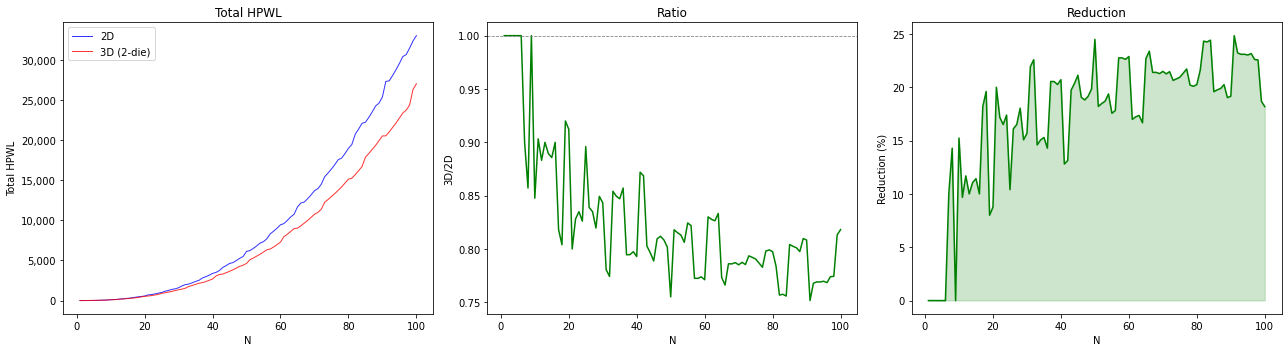

In [7]:
\
Ns=list(range(1,101)); data=[compute_all(n) for n in Ns]
wl2=[d[5] for d in data]; wl3=[d[6] for d in data]
ratios=[d[7] for d in data]; reductions=[d[8] for d in data]

fig,axes=plt.subplots(1,3,figsize=(18,5))
ax=axes[0]; ax.plot(Ns,wl2,"b-",lw=1,alpha=0.8,label="2D"); ax.plot(Ns,wl3,"r-",lw=1,alpha=0.8,label="3D (2-die)")
ax.set_xlabel("N"); ax.set_ylabel("Total HPWL"); ax.set_title("Total HPWL"); ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_:f"{x:,.0f}"))
ax=axes[1]; ax.plot(Ns,ratios,"g-",lw=1.5); ax.axhline(1.0,color="gray",ls="--",lw=0.8)
ax.set_xlabel("N"); ax.set_ylabel("3D/2D"); ax.set_title("Ratio")
ax=axes[2]; ax.fill_between(Ns,reductions,alpha=0.2,color="green"); ax.plot(Ns,reductions,"g-",lw=1.5)
ax.set_xlabel("N"); ax.set_ylabel("Reduction (%)"); ax.set_title("Reduction")
plt.tight_layout(); plt.show()
